# Hente data programmatisk

* Så langt har vi bladd igjennom statistikkbanken til ssb, funnet data vi er interessert i.
* Deretter har vi lastet det ned som csv-fil og lest det inn til pandas
 

* Dersom dataen er ferskvare, feks de forskjellige vareindeksene på ssb, valutakurser, aksjekurser osv har vi ikke tid til å laste ned dataen manuelt hver gang


* Da vil vi at python skal hente inn dataen for oss. 
* Vi kan for eksempel lage en valutakalkulator som automatisk henter inn de nyeste valutakursene
* For å se på hvordan dette kan gjøres i python må vi undersøke hvordan datanettverk er bygd opp

# OSI-modellen:
<img src="https://cf-assets.www.cloudflare.com/slt3lc6tev37/6ZH2Etm3LlFHTgmkjLmkxp/59ff240fb3ebdc7794ffaa6e1d69b7c2/osi_model_7_layers.png">

* Hvert lag i OSI-modellen har protokoller/måter å løse sine oppgaver på.
* For å hente data fra nettet bruker vi en protokoll i lag 7: **h**yper**t**ext **t**ransfer **p**rotocol

## Http: Hyptertext transfer protocol
<img src="https://study-ccna.com/wp-content/images/http_process_explained.jpg">

 * Http protokollen består av et sett regler/fremgangsmåter som følges av *klient* og *server*
 * Når vi skal laste inn en nettside, feks nrk.no, sender vi en *http-request* til nrk.no webserveren
 * nrk.no leser denne og sender tilbake en *http-respons* som inneholder diverse data pluss nettsiden i html-format
 * Nettleseren vår kan da vise nettsiden til nrk.no

# HTTP-request
<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*R8Li_PHLFdB-VyMtl8G5_w.png">

* Vi har et lite antall request-metoder, vi trenger:
    - *GET*: Ber om data eller en annen ressurs på webserver
    - *PUT*: Gir webserveren noe data som den skal gjøre noe med

# HTTP-request
<img src="https://www3.ntu.edu.sg/home/ehchua/programming/webprogramming/images/HTTP_RequestMessageExample.png">

 * Metodene består i alle tilfeller av 4 deler:
     - requestlinjen: GET/POST + ressurs-URI + HTTP-versjon
     - requestheaders: flere linjer av typen: *header-name: header-value*
     - en tom linje markerer slutt på headerern
     - data

# HTTP-respons

<img src="https://www3.ntu.edu.sg/home/ehchua/programming/webprogramming/images/HTTP_ResponseMessageExample.png">

* Responsen har også 4 deler:
    - Statuslinje
    - Responsheadere
    - blank linje
    - data


# Responskoder

* Statuslinjen gir en responskode med 3 siffer.
* Responskoder under 400 betyr at ting har gått greit.
* Du har kanskje sett:
    - 404: not found
    - 403: forbidden
* Dersom alt gikk greit sendes *200 OK*

<img src="https://preview.redd.it/3lsp5tedugt41.jpg?auto=webp&s=d26b8d5a5b6825ce14f3b872ad44f05e89ce67af">

# Web API
<img src="https://content.altexsoft.com/media/2021/03/rest_api_works.png.webp">

* Vi skal hente data fra ulike kilder ved å sende http-requests til forskjellige *web-apier*
* API er en forkortelse for **a**plication **p**rogramming **i**nterface og er en type protokoll eller måte for to programmer å snakke sammen
* I et webapi dreier det seg om kommunikasjon mellom en klient (pythonprogrammet ditt) og en server (ssb, eurostat etc)
* De kommer i mange former, et vanlig type API er bygget på REST-prinsipper


<img src="https://images.ctfassets.net/vwq10xzbe6iz/5sBH4Agl614xM7exeLsTo7/9e84dce01735f155911e611c42c9793f/rest-api.png" width="600px">

* Et http-request til et REST-API består av:
    - http-metode (GET PUT)
    - Et URL-endepunkt
    - Parametre/data
* Web-APIer gir typisk tilbake data i *xml* eller *json* format.
* Vi skal konsentrere oss om JSON

# JSON
* JSON er forkortelse for javascript object notation
* Det har nesten helt identisk form som et dictionary i python
* Noen forskjeller:
    - `None`er erstattet med `null`
    - `True/False` er erstattet med `true/false`

In [3]:
import json

minDict = {"Alder": 32,
           "Ansatt": True,
           "Verv": None,
           "fag": ["matematikk", "programmering"]
}

#json.dumps(dict) - printer ut dictionary som json-streng
print(json.dumps(minDict))

{"Alder": 32, "Ansatt": true, "Verv": null, "fag": ["matematikk", "programmering"]}


#### Nyttiger json-funksjoner
* `json.dump(fil, dictionary)` - skriver dictionary til json-fil
* `dictionary =json.load(fil)` - leser inn jsonfil til dictionary
* `dictionary =json.loads("strengrep av json objekt")` - leser json-streng til dict
* `tekst_rep = json.dumps(dictionary)` skriver dictionary til json-formatert tekststreng

In [11]:
# Eksempler
json_tekst = json.dumps(minDict) # Skriv dict om til json-formatert tekst
nyDict = json.loads(json_tekst) # Les json-formatert tekst til dict

with open("test.json", "w") as file: #Åpne fil "test.json" - vi skal skrive til filen (write = "w")
    json.dump(nyDict,file) # Skriv dictionary til json-fil

with open("test.json", "r") as file: #Åpne fil "test.json" - vi skal lese filen (read = "r")
    sisteDict = json.load(file)
sisteDict

{'Alder': 32,
 'Ansatt': True,
 'Verv': None,
 'fag': ['matematikk', 'programmering']}

# URL -- Uniform resource locator
`https://www.ntnu.no/sok?query=IIRA2001&category=all&sortby=magic`
* En url har flere deler: `protokoll://host/path?spørring`
* Protokollen er som regel `http://` (hypertext transfer protocoll)
  * Det finnes andre, feks `ftp`(file transfer protocoll)
* host er er "tjeneren" `feks www.nrk.no`, eller `www.ntnu.no`
* path er en sti på tjeneren feks `studies/courses/IIRA2001` er path til emnet på tjeneren ntnu.edu
* `?` Kalles en *separator* og bak separatoren kan vi "legge til litt data" eller en spørring
  * *Kalles typisk parametre*

## URL
<img src="https://wikis.ec.europa.eu/download/attachments/44165598/image_10.png?version=1&modificationDate=1651036868305&api=v2">

* Figuren viser et api-url fra eurostat
* Alt frem til spørsmålstegnet er api-endepunktet
* Spørsmålstegnet i url'en kalles en separator
* Bak separator i url kan man legge ved forskjellige *parametre*
     - Parameterverdiene har en egen tegnkoding `urlencoding`
     - De har form: `...?variabel1=verdi&variabel=verdi2`

# Hvordan?

* Hvordan parametre, url-endepunkt, http-metoder osv skal se ut er det web-api som bestemmer
* Skal vi bruke et web-api **MÅ VI LESE DOKUMENTASJONEN TIL API'ET**
    - Det forteller oss hvordan det skal brukes
    - Bruker ofte å være gode
    - Eksempler kan ofte finnes i python med `urllib` eller `requests` bibliotek
    - Eksempler på bruk også ofte gitt med `cURL`(et kommandolinjeverktøy)
* Noen API'er har også verktøy som lar deg bygge riktig url med et grafisk grensesnitt (feks SSB)

# Eksempelvis:

* [Trivia/quiz API](https://opentdb.com)

Vi fikk følgende url:
https://opentdb.com/api.php?amount=10&category=11

Vi kan bruke [CURL](https://reqbin.com/curl) til å sende api-spørringen/HTTP requestet


<img src="https://jvns.ca/images/curl.jpeg">

* Vi skal ikke bruke *curl*, men mange api'er bruker det i tutorials.
* Vi trenger kanskje å lese ut hva som er headere, parametre, url-endepunkt og data
    - `curl -G -d "parameter=value" http:/test.com/api` sender en GET request til `http:/test.com/api?parameter=value`


* Finner dere et kult API dere vil bruke og dokumentasjon/tutorials er gitt med curl kan dere spørre studass

# http requests i python!

* Da er vi klare til å bruke et web-api i python
* Der er 2 populære bibliotek:`urllib` og `requests`
* Vi anbefaler å bruke `requests`
* La oss gjøre noen sidesøk i wikipedia med python
* wikipedia API [her](https://www.mediawiki.org/wiki/API:REST_API)

In [23]:
import urllib
import json

limit = 5
query = input("Hva vil du søke etter?\n")
query_urlencoded = urllib.parse.quote(query)
url = f"https://en.wikipedia.org/w/rest.php/v1/search/page?q={query_urlencoded}&limit={limit}"

response = urllib.request.urlopen(url) #"åpne" url og motta resultat
data = response.read() #hent data
data_str = data.decode('utf-8')
data_dict = json.loads(data_str)

for page in data_dict["pages"]:
    print(page["title"], ":")
    print("------------------")
    print(page["description"],"\n\n")

print(query_urlencoded)

Hva vil du søke etter?
led zeppelin
Led Zeppelin :
------------------
English rock band (1968–1980) 


Led Zeppelin IV :
------------------
1971 studio album by Led Zeppelin 


Led Zeppelin (album) :
------------------
1969 studio album by Led Zeppelin 


Led Zeppelin III :
------------------
1970 studio album by Led Zeppelin 


Led Zeppelin II :
------------------
1969 studio album by Led Zeppelin 


led%20zeppelin


In [13]:
#Anbefaler å bruke requests
#!pip install requests_toolbelt
import requests
from requests_toolbelt.utils import dump #Fordi jeg vil undersøke nøyaktig hva som blir sendt
import pprint

pp = pprint.PrettyPrinter(indent=4)

search =input("Hva vil du søke etter?\n")

#URL endepunkt sidesøk på wiki-api 
url_endpoint = "https://en.wikipedia.org/w/rest.php/v1/search/page"

#Søkeresultat
num_results = 5

# Med requests lager vi dictionaries med headere og parametere
parameters = {"q": search, "limit": num_results}

# requests fyller ut mange headere automatisk også
header = {"Connection": "Close"}

#Send get-request
response = requests.get(url_endpoint, headers=header, params=parameters)
req = requests.Request("get", url_endpoint, headers=header, params=parameters)

http_melding = dump.dump_all(response)
pp.pprint(http_melding.decode('utf-8'))

#print("Tilgjenglige metoder til responsen: ", dir(response))

data = response.json() # Dersom vi får json tilbake
#data = resonse.text # Dersom vi får noe annet enn json tilbake

print("\n\nExit code:", response.status_code)
print("URL: ", response.url)
print("headers", response.headers)

for page in data["pages"]:
    print(page["title"], ":")
    print("------------------")
    print(page["description"],"\n\n")


Hva vil du søke etter?
 Led zeppelin


('< GET /w/rest.php/v1/search/page?q=Led+zeppelin&limit=5 HTTP/1.1\r\n'
 '< Host: en.wikipedia.org\r\n'
 '< User-Agent: python-requests/2.32.2\r\n'
 '< Accept-Encoding: gzip, deflate, br, zstd\r\n'
 '< Accept: */*\r\n'
 '< Connection: Close\r\n'
 '< \r\n'
 '\r\n'
 '> HTTP/1.1 200 OK\r\n'
 '> date: Thu, 07 Nov 2024 06:53:14 GMT\r\n'
 '> server: mw-api-ext.eqiad.main-7f76f795d6-7mjrk\r\n'
 '> x-content-type-options: nosniff\r\n'
 '> cache-control: no-cache\r\n'
 '> access-control-allow-origin: *\r\n'
 '> content-type: application/json\r\n'
 '> content-encoding: gzip\r\n'
 '> vary: x-restbase-compat, Accept-Encoding\r\n'
 '> age: 0\r\n'
 '> x-cache: cp3071 miss, cp3071 pass\r\n'
 '> x-cache-status: pass\r\n'
 '> server-timing: cache;desc="pass", host;desc="cp3071"\r\n'
 '> strict-transport-security: max-age=106384710; includeSubDomains; '
 'preload\r\n'
 '> report-to: { "group": "wm_nel", "max_age": 604800, "endpoints": [{ "url": '
 '"https://intake-logging.wikimedia.org/v1/events?stream=

# Eurostats api:

* Eurostat api: [https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-detailed-guidelines/api-statistics](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-detailed-guidelines/api-statistics)


In [3]:
import requests
import pprint

pp = pprint.PrettyPrinter()

tabell = "nama_10_gdp"
url_endpoint  = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{tabell}"
parameters = {
    "format": "JSON",
    "lang": "EN",
    "sinceTimePeriod": 2019
}

response = requests.get(url_endpoint, params=parameters)
data = response.json()
pp.pprint(data)

{'class': 'dataset',
 'dimension': {'freq': {'category': {'index': {'A': 0},
                                     'label': {'A': 'Annual'}},
                        'label': 'Time frequency'},
               'geo': {'category': {'index': {'AL': 40,
                                              'AT': 24,
                                              'BA': 37,
                                              'BE': 5,
                                              'BG': 6,
                                              'CH': 35,
                                              'CY': 17,
                                              'CZ': 7,
                                              'DE': 9,
                                              'DK': 8,
                                              'EA': 1,
                                              'EA12': 4,
                                              'EA19': 3,
                                              'EA20': 2,
                          

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



# JSON-stat

* Man får gjerne statistisk data tilbake i json_stat-format
* Vi kan bruke `pyjstat` til å lese data inn til pandas

In [4]:
#!pip install pyjstat
from pyjstat import pyjstat
import pandas as pd


#dataset = pyjstat.Dataset.read(json.dumps(data))
dataset = pyjstat.Dataset.read(response.text) #Les data som json-streng, ikke dict-objekt
tittel = dataset["label"]
GDP_id = dataset.write('dataframe', naming='id')
GDP_df = dataset.write('dataframe')
GDP_orig = pd.DataFrame(GDP_df, copy=True)

In [7]:
GDP_df = GDP_orig

GDP_df["Time frequency"].unique
#Kun årlige tall - vi dropper hele kolonnen
GDP_df = GDP_df.drop(columns="Time frequency")

GDP_df = GDP_df.astype({"value": "float64"})
GDP_df["Time"] = pd.PeriodIndex(GDP_df["Time"], freq="Y")

GDP_df["Unit of measure"].unique()
enhet = ['Chain linked volumes, index 2020=100',
      'Previous year prices, million euro']
GDP_df.query("`Unit of measure` in @enhet")

GDP_df["National accounts indicator (ESA 2010)"].unique()

GDP_df = GDP_df.query("`National accounts indicator (ESA 2010)` == 'Compensation of employees'").drop(columns="National accounts indicator (ESA 2010)")
GDP_df = GDP_df.dropna()
GDP_df = GDP_df.rename(columns={"Geopolitical entity (reporting)": "region"})
GDP_df = GDP_df.pivot(columns="Unit of measure", index=["region", "Time"], values="value")
GDP_df

Unit of measure      Current prices, million euro  \
region         Time                                 
Austria        2019                      192668.1   
               2020                      192083.9   
               2021                      201416.4   
               2022                      217424.0   
               2023                      234829.5   
...                                           ...   
Türkiye        2020                      183573.3   
               2021                      185135.7   
               2022                      203108.8   
               2023                      297414.8   
United Kingdom 2019                     1251553.4   

Unit of measure      Current prices, million purchasing power standards (PPS, EU27 from 2020)  \
region         Time                                                                             
Austria        2019                                           169679.8                          
               2020                                           168352.9                          
               2021                                           178014.6                          
               2022                                           193618.6                          
               2023                                           207325.7                          
...                                                                ...                          
Türkiye        2020                                           447400.7                          
               2021                                           450261.7                          
               2022                                           476427.8                          
               2023                                           687150.6                          
United Kingdom 2019                                          1066713.3                          

Unit of measure      Current prices, million units of national currency  \
region         Time                                                       
Austria        2019                                           192668.1    
               2020                                           192083.9    
               2021                                           201416.4    
               2022                                           217424.0    
               2023                                           234829.5    
...                                                                ...    
Türkiye        2020                                          1478627.9    
               2021                                          1946220.4    
               2022                                          3535880.0    
               2023                                          7661316.8    
United Kingdom 2019                                          1098576.0    

Unit of measure      Percentage of EU27 (from 2020) total (based on million euro), current prices  \
region         Time                                                                                 
Austria        2019                                                2.9                              
               2020                                                2.9                              
               2021                                                2.9                              
               2022                                                2.9                              
               2023                                                2.9                              
...                                                                ...                              
Türkiye        2020                                                2.8                              
               2021                                                2.6                              
               2022                                           

<Axes: ylabel='Current prices, million euro'>

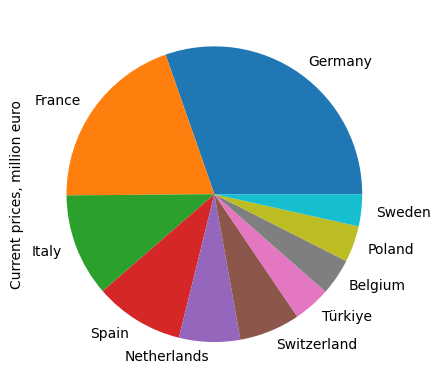

In [6]:
import matplotlib.pyplot as plt
top10_GDP = GDP_df.xs("2023", level="Time")\
    .query("not region.str.contains('Euro')")\
    .sort_values("Current prices, million euro", ascending=False)\
    .head(10)

top10_GDP
top10_GDP.plot.pie(y="Current prices, million euro", legend=False)